In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [2]:
import torch.nn as nn

class MLPModel(nn.Module):
    def __init__(self, input_dim=10, hidden_dim=64, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)
    
class LorentzScalarDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.scale = nn.Parameter(torch.tensor(0.5))
        self.offset = nn.Parameter(torch.tensor(0.0))

    def forward(self, x1):
        return self.scale * x1 + self.offset

In [3]:
def productopunto(u, v):
    return -u[:, 0] * v[:, 0] + torch.sum(u[:, 1:] * v[:, 1:], dim=1)
    
def lorentz_distance(u, v, eps=1e-5):
    ip = productopunto(u, v)
    ip = torch.clamp(ip, min=1 + eps) 
    return torch.acosh(ip)
    
def lorentz_norm_penalty(x):
    norm = -x[:, 0]**2 + torch.sum(x[:, 1:]**2, dim=1)
    return torch.mean((norm + 1)**2)

class HyperbolicLoss(nn.Module): #Funcion de perdida custom
    def __init__(self, alpha=1.0, beta=0.5, gamma=1.0, delta=1.0): #se inicializan los valores
        super(HyperbolicLoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.delta = delta

    def forward(self, predictions, targets): #el forward decomo se va calculando la perdida
        loss_l2 = torch.norm(predictions - targets, p=2) ** 2 #la norma 2 al cuadrado del error
        loss_l1 = torch.norm(predictions - targets, p=1) #esta es la norma del error, pero mas adelante la dessactivo porque la cambiamos por el weight penalty
        geom_error = lorentz_norm_penalty(predictions)
        norm_geom = torch.norm(geom_error, p=1) #la norma 1 del error geometrico

        return self.alpha * loss_l2 + self.beta * loss_l1 + self.gamma * geom_error + self.delta * norm_geom
    
def projection(y):
    y = y.view(-1, 1)
    time_component = torch.sqrt(1 + y**2)
    return torch.cat([time_component, y], dim=1)

In [23]:
data = pd.read_csv('SRU2Limpio.csv')

X = data.iloc[:,:10].values.astype(np.float32)
y = data.iloc[:,10].values.astype(np.float32)

scalerx = StandardScaler()
scalery = StandardScaler()

Xscaled = scalerx.fit_transform(X)
yscaled = scalery.fit_transform(y.reshape(-1,1)).flatten()

xtensor = torch.tensor(Xscaled)
ytensor = torch.tensor(yscaled)

print(f'shape input: {xtensor.shape}, shape output: {ytensor.shape}')

shape input: torch.Size([84241, 10]), shape output: torch.Size([84241])


In [24]:
from torch.utils.data import DataLoader, TensorDataset

n = len(xtensor)
n_train = int(0.7 * n)
n_val = int(0.15 * n)
n_test = n - n_train - n_val

X_train = xtensor[:n_train]
y_train = ytensor[:n_train]

X_val = xtensor[n_train:n_train + n_val]
y_val = ytensor[n_train:n_train + n_val]

X_test = xtensor[n_train + n_val:]
y_test = ytensor[n_train + n_val:]

batch_size = 64

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=False)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

#hiperparametros
alpha = 0
beta = 0
gamma = 1
delta = 1
lr= 0.0001
epochs = 60
lambdal2 = 1

model = MLPModel(input_dim=10, output_dim=2).to(device)
decoder = LorentzScalarDecoder().to(device)
criterion = HyperbolicLoss(alpha=alpha, beta=beta, gamma=gamma, delta=delta)
params = list(model.parameters()) + list(decoder.parameters())
optimizer = torch.optim.Adam(params, lr=lr)

Epoch 1 ||  Train Loss: 0.298457,  Validation Loss: 1.062963
Epoch 2 ||  Train Loss: 0.100603,  Validation Loss: 0.560515
Epoch 3 ||  Train Loss: 0.071723,  Validation Loss: 0.195484
Epoch 4 ||  Train Loss: 0.062131,  Validation Loss: 0.015037
Epoch 5 ||  Train Loss: 0.057049,  Validation Loss: 0.066096
Epoch 6 ||  Train Loss: 0.045808,  Validation Loss: 0.215082
Epoch 7 ||  Train Loss: 0.035706,  Validation Loss: 0.337174
Epoch 8 ||  Train Loss: 0.028920,  Validation Loss: 0.402245
Epoch 9 ||  Train Loss: 0.024696,  Validation Loss: 0.424759
Epoch 10 ||  Train Loss: 0.022147,  Validation Loss: 0.422911
Epoch 11 ||  Train Loss: 0.020459,  Validation Loss: 0.408183
Epoch 12 ||  Train Loss: 0.019240,  Validation Loss: 0.387545
Epoch 13 ||  Train Loss: 0.018272,  Validation Loss: 0.364912
Epoch 14 ||  Train Loss: 0.017526,  Validation Loss: 0.342105
Epoch 15 ||  Train Loss: 0.016921,  Validation Loss: 0.319611
Epoch 16 ||  Train Loss: 0.016405,  Validation Loss: 0.297960
Epoch 17 ||  Trai

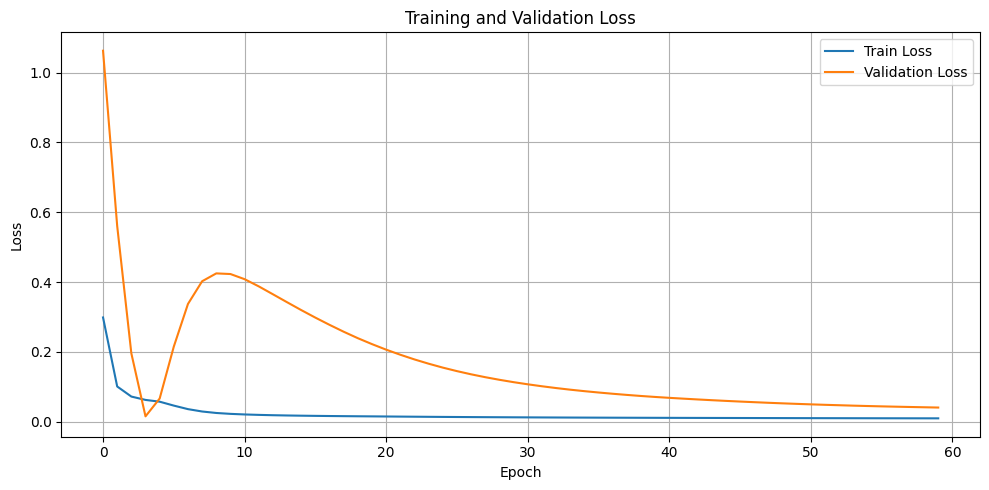

In [25]:
train_losses = []
val_losses = []

previous_params =0
previous_params = [param.detach().clone() for param in model.parameters() if param.requires_grad]

for epoch in range(epochs):
    model.train()
    decoder.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        ylorentz = projection(y_batch)
        loss = criterion(outputs, ylorentz)

        #weight penalty
        l2penalty = 0
        for param, prev_param in zip(model.parameters(), previous_params):
            if param.requires_grad:
                l2penalty += torch.norm(param-prev_param, p=2)**2

        #decoder penalty
        decpred = decoder(outputs)
        eucloss = torch.nn.functional.mse_loss(decpred, ylorentz)
        losstotal = loss + lambdal2*l2penalty + eucloss
        #####
        losstotal.backward()
        optimizer.step()
    
        train_loss += loss.item()
        
    previous_params = [p.detach().clone() for p in model.parameters() if p.requires_grad]
        
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    decoder.eval()
    val_loss = 0
    with torch.no_grad():     
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            decode = decoder(outputs)
            ylorentz = projection(y_batch)
            loss = criterion(decode, ylorentz)
            val_loss += loss.item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f'Epoch {epoch+1} ||  Train Loss: {train_loss:.6f},  Validation Loss: {val_loss:.6f}')

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

(12636,)
(12636,)


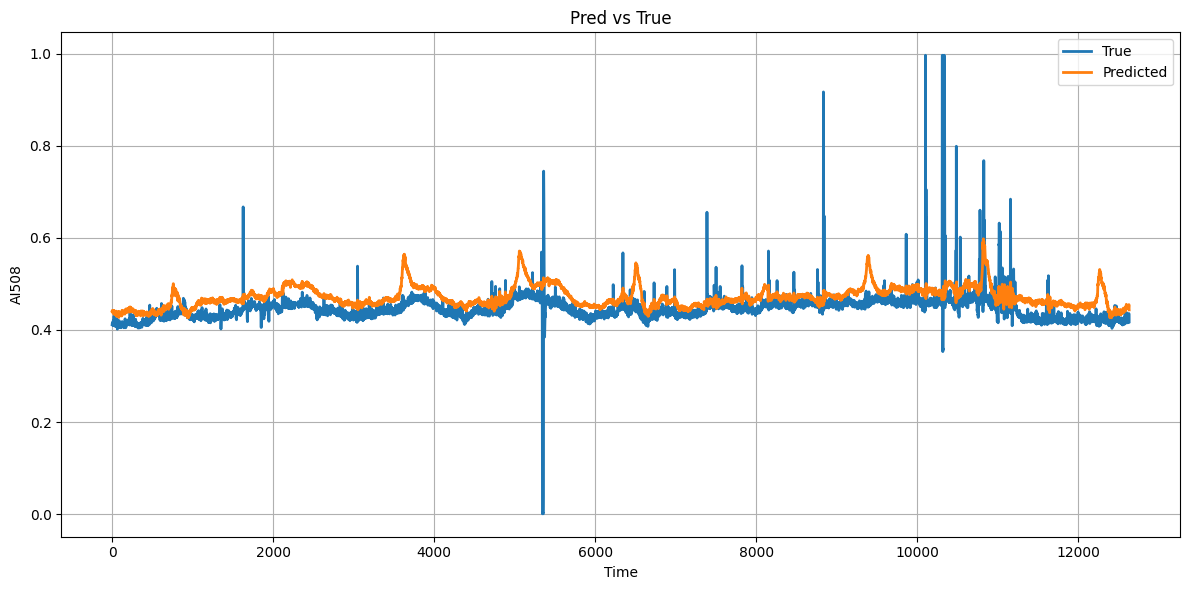

In [26]:
model.eval()
decoder.eval()
all_preds = []
all_targets = []
predsnormal = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch)[:, 1] 
        decode = decoder(preds)
        all_preds.append(decode.cpu())
        predsnormal.append(preds.cpu())
        all_targets.append(y_batch)

all_preds = scalery.inverse_transform(torch.cat(all_preds).squeeze().numpy().reshape(-1, 1)).flatten()
all_targets = scalery.inverse_transform(torch.cat(all_targets).squeeze().numpy().reshape(-1, 1)).flatten()

predsnormal = scalery.inverse_transform(torch.cat(predsnormal).squeeze().numpy().reshape(-1, 1)).flatten()

print(all_preds.shape)
print(all_targets.shape)
plt.figure(figsize=(12, 6))
plt.plot(all_targets, label='True', linewidth=2)
plt.plot(all_preds, label='Predicted', linewidth=2)
#plt.plot(predsnormal, label='Predicted normal', linewidth=2)
plt.xlabel('Time')
plt.ylabel('AI508')
plt.title('Pred vs True')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

r2 = r2_score(all_targets, all_preds)
mse = mean_squared_error(all_targets, all_preds)
mae = mean_absolute_error(all_targets, all_preds)
mape = mean_absolute_percentage_error(all_targets, all_preds)

print("\Test Metrics:")
print(f"R² Score: {r2:.8f}")
print(f"MSE: {mse:.8f}")
print(f"MAE: {mae:.8f}")
print(f"MAPE: {mape:.8f}")

\Test Metrics:
R² Score: -0.52779567
MSE: 0.00163535
MAE: 0.02893140
MAPE: 0.47741148


<>:8: SyntaxWarning: invalid escape sequence '\T'
<>:8: SyntaxWarning: invalid escape sequence '\T'
C:\Users\Tomás\AppData\Local\Temp\ipykernel_24520\2102768520.py:8: SyntaxWarning: invalid escape sequence '\T'
  print("\Test Metrics:")


(12637,)
(12637,)


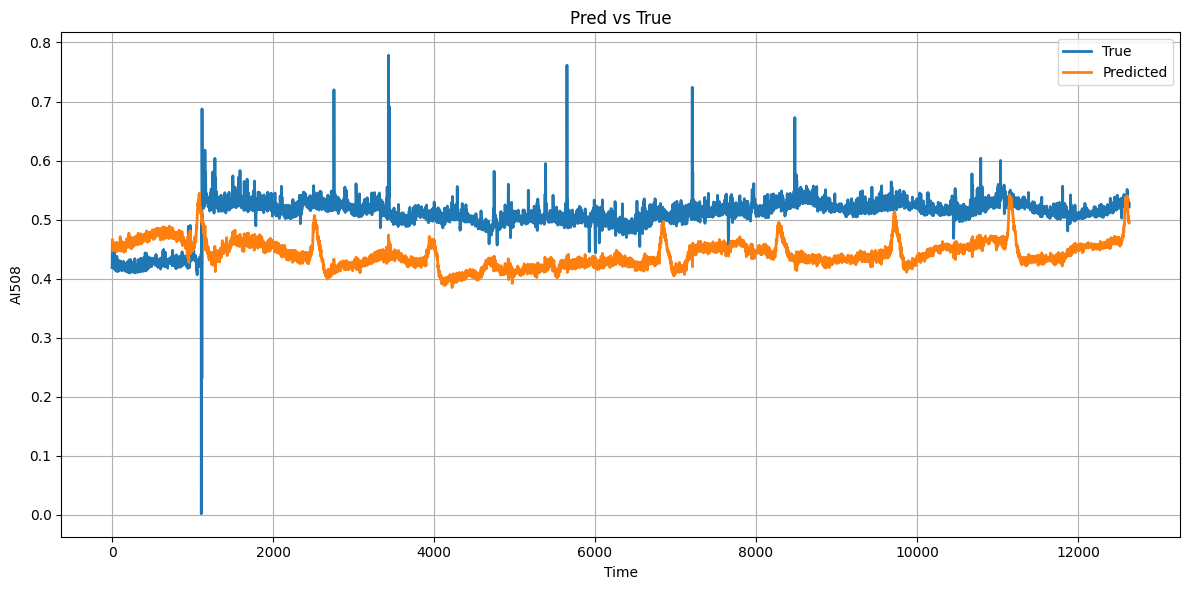

In [9]:
model.eval()
decoder.eval()
all_preds = []
all_targets = []
predsnormal = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch)[:, 1] 
        decode = decoder(preds)
        all_preds.append(decode.cpu())
        predsnormal.append(preds.cpu())
        all_targets.append(y_batch)

all_preds = scalery.inverse_transform(torch.cat(all_preds).squeeze().numpy().reshape(-1, 1)).flatten()
all_targets = scalery.inverse_transform(torch.cat(all_targets).squeeze().numpy().reshape(-1, 1)).flatten()

predsnormal = scalery.inverse_transform(torch.cat(predsnormal).squeeze().numpy().reshape(-1, 1)).flatten()

print(all_preds.shape)
print(all_targets.shape)
plt.figure(figsize=(12, 6))
plt.plot(all_targets, label='True', linewidth=2)
plt.plot(all_preds, label='Predicted', linewidth=2)
#plt.plot(predsnormal, label='Predicted normal', linewidth=2)
plt.xlabel('Time')
plt.ylabel('AI508')
plt.title('Pred vs True')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2 = r2_score(all_targets, all_preds)
mse = mean_squared_error(all_targets, all_preds)
mae = mean_absolute_error(all_targets, all_preds)

print("\Test Metrics:")
print(f"R² Score: {r2:.8f}")
print(f"MSE: {mse:.8f}")
print(f"MAE: {mae:.8f}")

\Test Metrics:
R² Score: -5.25374317
MSE: 0.00586323
MAE: 0.07312174


<>:7: SyntaxWarning: invalid escape sequence '\T'
<>:7: SyntaxWarning: invalid escape sequence '\T'
C:\Users\Tomás\AppData\Local\Temp\ipykernel_24520\4117103884.py:7: SyntaxWarning: invalid escape sequence '\T'
  print("\Test Metrics:")
